<a href="https://colab.research.google.com/github/priyansh-commits/Deep_Learning/blob/main/dl_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import math

def sigmoid(x):
    x = max(-500.0, min(500.0, x))
    return 1.0 / (1.0 + math.exp(-x))

In [47]:
class Layer:
    def __init__(self, n_inputs, n_neurons, weights=None, biases=None):
        if weights is not None:
            self.weights = weights
        else:
            import random
            self.weights = [
                [random.uniform(-1, 1) for _ in range(n_inputs)]
                for _ in range(n_neurons)
            ]
        if biases is not None:
            self.biases = biases
        else:
            self.biases = [0.0] * n_neurons

    def forward(self, inputs):
        self.last_input = inputs
        self.last_output = []
        for neuron_idx in range(len(self.weights)):
            z = sum(
                w * x for w, x in zip(self.weights[neuron_idx], inputs)
            )
            z += self.biases[neuron_idx]
            self.last_output.append(sigmoid(z))
        return self.last_output

In [48]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, inputs):
        current = inputs
        for layer in self.layers:
            current = layer.forward(current)
        return current

In [49]:
hidden = Layer(
    n_inputs=2,
    n_neurons=2,
    weights=[[20.0, 20.0], [-20.0, -20.0]],
    biases=[-10.0, 30.0],
)

output = Layer(
    n_inputs=2,
    n_neurons=1,
    weights=[[20.0, 20.0]],
    biases=[-30.0],
)

xor_net = Network([hidden, output])

xor_data = [
    ([0, 0], 0),
    ([0, 1], 1),
    ([1, 0], 1),
    ([1, 1], 0),
]

for inputs, expected in xor_data:
    result = xor_net.forward(inputs)
    predicted = 1 if result[0] >= 0.5 else 0
    print(f"  {inputs} -> {result[0]:.6f} (rounded: {predicted}, expected: {expected})")

  [0, 0] -> 0.000045 (rounded: 0, expected: 0)
  [0, 1] -> 0.999955 (rounded: 1, expected: 1)
  [1, 0] -> 0.999955 (rounded: 1, expected: 1)
  [1, 1] -> 0.000045 (rounded: 0, expected: 0)


In [50]:
import random
import math

random.seed(42)

data = []
for _ in range(200):
    x = random.uniform(-1, 1)
    y = random.uniform(-1, 1)
    label = 1 if (x * x + y * y) < 0.25 else 0
    data.append(([x, y], label))

circle_net = Network([
    Layer(n_inputs=2, n_neurons=8),
    Layer(n_inputs=8, n_neurons=1),
])
correct = 0
for inputs, expected in data:
    result = circle_net.forward(inputs)
    predicted = 1 if result[0] >= 0.5 else 0
    if predicted == expected:
        correct += 1

print(f"Accuracy with random weights: {correct}/{len(data)} ({100*correct/len(data):.1f}%)")


Accuracy with random weights: 165/200 (82.5%)


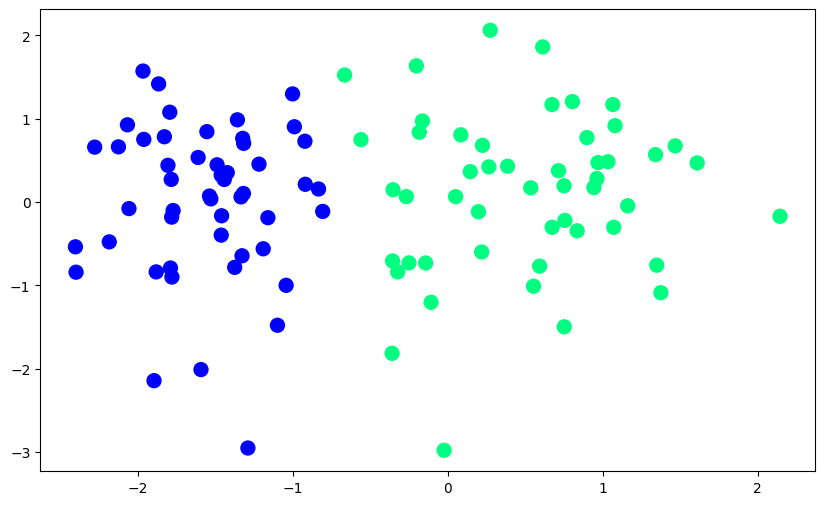

In [51]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [52]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]
def step(z):
    return 1 if z>0 else 0

[1.42266404 0.08361187]
0.9


(-3.0, 2.0)

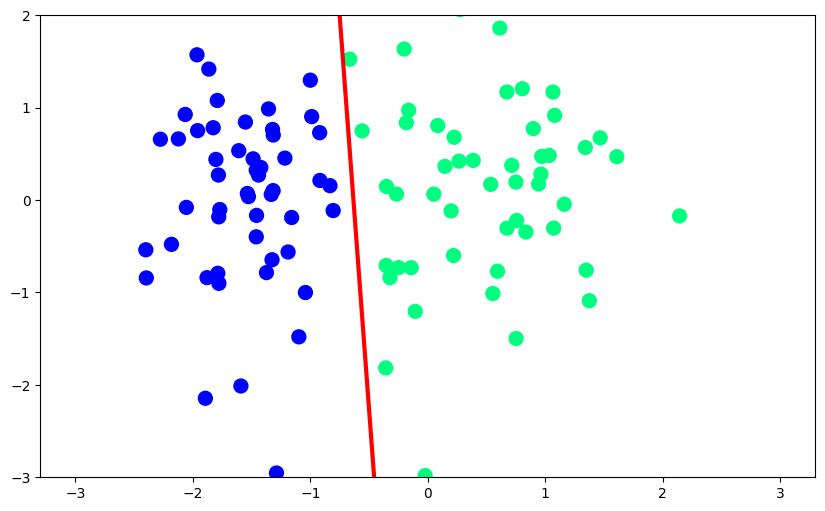

In [53]:
intercept_,coef_ = perceptron(X,y)
print(coef_)
print(intercept_)
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [54]:
X_1=np.insert(X,0,1,axis=1)
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [55]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [74]:
def per(X,y):
  for i in range(2000):
    w = np.array([1., 1., 1.])

    lr=0.1
    for j in range(X.shape[0]):
      z = -y[j] * np.dot(w, X[j])
      if z > 0:
            w = w + lr * y[j] * X[j]
  return w





In [75]:
w1,w2,b = per(X_1,y)
w = per(X_1,y)
print(w1,w2,b)
# [1.25192201 0.05225512]
# 1.0

1.3000000000000003 0.9265860822077007 0.44943303924033684


-1.4029997050059255 -0.4850418626723915


(-3.0, 2.0)

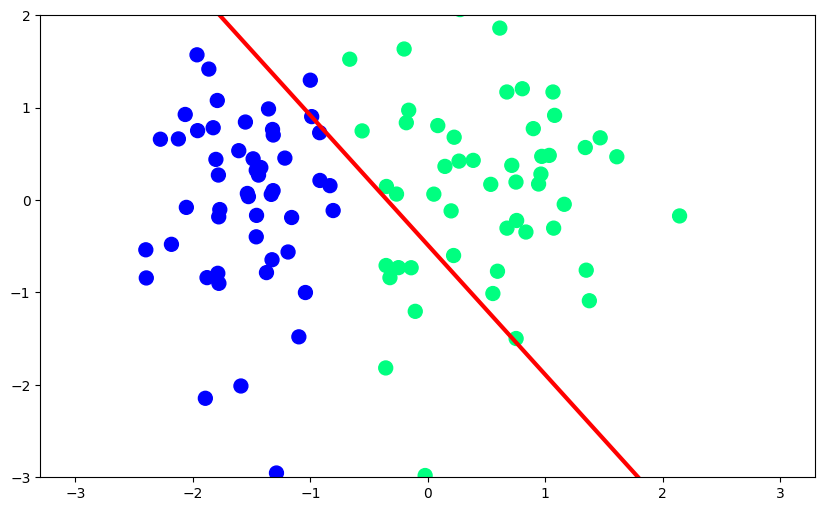

In [76]:
m = -(w1/w2)
c = -(b/w2)

print(m,c)
# -4.531321834268464 -5.851870329508209
x_input = np.linspace(-3,3,100)
y_input = m*x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [77]:
pred = np.sign(np.dot(X_1, w))

accuracy = np.mean(pred == y)

print("Accuracy:", accuracy)

Accuracy: 0.49


In [78]:
def per(X, y):
    w0 = 1
    w1 = 1
    w2 = 1
    lr = 0.01

    for i in range(2000):
        for j in range(X.shape[0]):
            z = -y[j] * np.dot([w0, w1, w2], X[j])

            if z > 0:
                w0 += lr * y[j] * X[j][0]
                w1 += lr * y[j] * X[j][1]
                w2 += lr * y[j] * X[j][2]

    return w1, w2, w0
w1, w2, w0 = per(X_1, y)

pred = np.sign(np.dot(X_1, [w0, w1, w2]))

print(np.mean(pred == y) * 100)

50.0
